# Convection Areas with Biogeochemistry Model MLD

## Package imports

In [1]:
# filter some warning messages
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import scipy
from scipy import stats
import numpy as np
import pandas as pd
import xarray as xr
from os import path
# import xesmf as xe
import scipy.signal as signal
from scipy.signal import detrend
import turtle
import dask.array as da
import intake
import cartopy.crs as ccrs
import gsw
import pickle as pkl
from datetime import datetime


os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'
warnings.filterwarnings("ignore")
# import PyCO2SYS as pyco2


import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client


## plotting stuff
import cartopy.crs as ccrs # for map projections
import cartopy.feature as cfeature # for map features like coastline, etc.
from cartopy.util import add_cyclic_point # get rid of the white line at 0 degree longitude for some models
import matplotlib.path as mpath
import cmocean # a nice collection of colormap

## Cluster Creation

In [49]:
'''#
cluster = PBSCluster(
    job_name='dask',
    cores=1,
    memory='16GiB',
    processes=1,
    resource_spec='select=1:ncpus=1:mem=16GB',
    queue='casper',
    walltime='01:00:00',
    interface='ext',
    local_directory='${SCRATCH}/dask_scratch/pbs.$PBS_JOBID/dask/spill',
)

cluster.adapt(minimum=2, maximum=50)
client = Client(cluster)
client
#'''


"#\ncluster = PBSCluster(\n    job_name='dask',\n    cores=1,\n    memory='16GiB',\n    processes=1,\n    resource_spec='select=1:ncpus=1:mem=16GB',\n    queue='casper',\n    walltime='01:00:00',\n    interface='ext',\n    local_directory='${SCRATCH}/dask_scratch/pbs.$PBS_JOBID/dask/spill',\n)\n\ncluster.adapt(minimum=2, maximum=50)\nclient = Client(cluster)\nclient\n#"

## Pulling CMIP DATA Function

In [2]:
def get_path(model, variable, data_type, experiment_id, activity_id):
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path


## Specify Models & variables

In [3]:
model = "GFDL-CM4"
variable = "spco2"

## Create Convection Masks

Deep Convection will be defined as areas where the mixed layer depth (MLD) reached a depth greater than 2000 meters in the month of september (SO winter). Right now I will use the models saved version of MLD. 

**Pull MLD Data**

In [4]:
#get the path to the MLD data for the choosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling MLD data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 

path_mld = get_path(model,"mlotst", "Omon", "piControl","CMIP")
#print(path_mld)

In [5]:
MODEL_MLD = xr.open_mfdataset(path_mld, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
MODEL_MLD_SO = MODEL_MLD.sel(lat=slice(-90, -40)) #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_MLD_SO_sept = MODEL_MLD_SO.sel(time=MODEL_MLD_SO['time'].dt.month == 9) # pull the september month data (results in 500 point time dimension - 1 month for 500 yrs) 

#display dataset to see vars and dimesions 
MODEL_MLD_SO_sept 

<xarray.Dataset> Size: 39MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d9acf7e3-3970-44c5-bb0d-57ec2bc0c5ad
    variable_id:            mlotst
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

**Deep Convection Area Mask**

For every year in the 500 year time period, check if the MLD is greater than or equal to 2000 m. If it is then write a value of 1, if it is not, write a value of zero. Results in a mask with dimensions of lat, lon, time 

In [6]:
#1 where the mixed-layer depth (MLD) is ≥ 2000 (“deep convection” criterion), and 0 everywhere else
convection_area_mask = xr.where(MODEL_MLD_SO_sept>=2000, 1, 0)  # this is the mask of deep convection (x, y, t)

#display mask to check dimensions and vars
convection_area_mask

<xarray.Dataset> Size: 75MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) int64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) int64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) int64 72MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) int64 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>

**Not Convection Area Mask**

The reverse of the convection area mask, gives a 1 where MLD is less than 2000, everywhere else is 0 

In [7]:
NOTconvection_area_mask = xr.where(MODEL_MLD_SO_sept < 2000, 1, 0)  # this is the mask of deep convection (x, y, t)
#1 where the mixed-layer depth (MLD) is < 2000 (“deep convection” criterion), and 0 everywhere else

#display mask to check dimensions and vars
NOTconvection_area_mask

<xarray.Dataset> Size: 75MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) int64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) int64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) int64 72MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) int64 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>

**Total Convection Area Mask**

This mask gives the total area than has deep convection in any of the 500 years, sort of the total area that has potential for deep convection. Gives a 1 for the area that is deep convection  

In [9]:
convection_total_mask = xr.where(convection_area_mask.mean("time") > 0, 1, 0)   # this is the mask of total convection area (x, y)
# gives a one wherever deep convection has occured in any of the 500 years

#display mask to check dimensions and vars
convection_total_mask

<xarray.Dataset> Size: 154kB
Dimensions:    (lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) int64 800B dask.array<chunksize=(50, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) int64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    mlotst     (lat, lon) int64 144kB dask.array<chunksize=(50, 360), meta=np.ndarray>
    time_bnds  (bnds) int64 16B dask.array<chunksize=(2,), meta=np.ndarray>

## Biogeochemical Data

In [10]:
#get the path to the po4 data for the choosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling po4 data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 
    #note pulling po4 for GFDL-CM4 b/c it does not have a no3 feild 
a
path_var = get_path(model ,variable, "Omon", "piControl","CMIP")
#print(path)

In [11]:
MODEL_VAR = xr.open_mfdataset(path_var, chunks = None)  # open po4 data into a xarray dataset (opens all files as one dataset) 
MODEL_VAR_SO = MODEL_VAR.sel(lat=slice(-90, -40))  #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_VAR_SO_sept = MODEL_VAR_SO.sel(time=MODEL_VAR_SO['time'].dt.month == 9) # pull the September month data (results in 500 point time dimension - 1 month for 500 yrs) 

if 'lev' in MODEL_VAR_SO_sept.coords:
    MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept.isel(lev=0) #Pull only surface levels of nutrient for now 
else: 
    MODEL_VAR_SO_sept_surface =  MODEL_VAR_SO_sept
#display mask to check dimensions and vars

MODEL_VAR_SO_sept_surface 

<xarray.Dataset> Size: 111MB
Dimensions:    (time: 500, lat: 50, lon: 360, bnds: 2)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    geolat     (time, lat, lon) float32 36MB dask.array<chunksize=(240, 50, 360), meta=np.ndarray>
    geolon     (time, lat, lon) float32 36MB dask.array<chunksize=(240, 50, 360), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    spco2      (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d79706ae-6a8c-4765-ad20-7cb43ec718eb
    variable_id:            spco2
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

## Deep Convection Areas

In [12]:
##Convection masked areas 
# ensure mask is boolean, same dims
mask_deepConvection = (convection_area_mask == 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned, VAR_aligned = xr.align(mask_deepConvection, MODEL_VAR_SO_sept_surface)

VAR_deepconvection = VAR_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
VAR_deepconvection

<xarray.Dataset> Size: 540MB
Dimensions:    (time: 500, lat: 50, lon: 360, bnds: 2)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    geolat     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    geolon     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    spco2      (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d79706ae-6a8c-4765-ad20-7cb43ec718eb
    variable_id:            spco2
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [13]:
#flatten time dimension (average over time), pull po4 data//
##to make the dataset into a (flat) dataarray that can be mapped 
### renamed "_plot" version to preserve original dataset for future computations" 
VAR_deepconvection_plot = VAR_deepconvection[variable].mean("time")
#ensure dimensions align with expectations (360 x (longitude), 50 y (latitude) 
VAR_deepconvection_plot 

<xarray.DataArray 'spco2' (lat: 50, lon: 360)> Size: 72kB
dask.array<mean_agg-aggregate, shape=(50, 360), dtype=float32, chunksize=(50, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

**Create Map of Deep Convection area**

Text(0.5, 1.0, 'PCO2 [Pa] in GFDL-CM4 Deep Convection Areas (time averaged)')

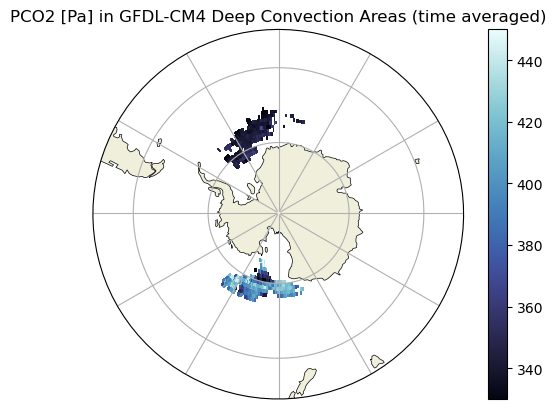

In [14]:
#mapping code 
ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
VAR_deepconvection_plot_c = (VAR_deepconvection_plot * 1000) / 101.325

# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(VAR_deepconvection_plot.lon, VAR_deepconvection_plot.lat, VAR_deepconvection_plot_c, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice,vmin=330, vmax = 450) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('PCO2 [Pa] in GFDL-CM4 Deep Convection Areas (time averaged)') 

**Count Number of Data Points in this Catagory**

In [15]:
n_data_deepconvection = (VAR_deepconvection[variable]).count().compute().values
n_data_deepconvection

array(2062)

**Calculate Mean of Variable**

In [16]:
VAR_deepconvection_MEAN = VAR_deepconvection[variable].mean('time').mean('lat').mean('lon').values
VAR_deepconvection_MEAN = (VAR_deepconvection_MEAN * 1000) / 101.325 # unit conversion
VAR_deepconvection_MEAN

373.049457662052

## Not deep Convection areas ALL

random extra ... not super useful

In [21]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_NOTdeepConvection = (NOTconvection_area_mask == 1)

# align mask to PO4 before applying
mask_NOTdeepConvection_aligned, PO4_aligned = xr.align(mask_NOTdeepConvection, GFDL_CM4_PO4_SO_sept_surface)

PO4_NOTdeepconvection = PO4_aligned.where(mask_NOTdeepConvection_aligned['mlotst'])

PO4_NOTdeepconvection

NameError: name 'GFDL_CM4_PO4_SO_sept_surface' is not defined

In [67]:
PO4_NOTdeepconvection_plot = PO4_NOTdeepconvection['po4'].mean("time")
PO4_NOTdeepconvection_plot

<xarray.DataArray 'po4' (lat: 50, lon: 360)> Size: 72kB
dask.array<mean_agg-aggregate, shape=(50, 360), dtype=float32, chunksize=(50, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lev      float64 8B 2.5

Text(0.5, 1.0, 'PO4 [mmol/m^3]in GFDL-CM4 NOT Deep Convection Areas (time averaged)')

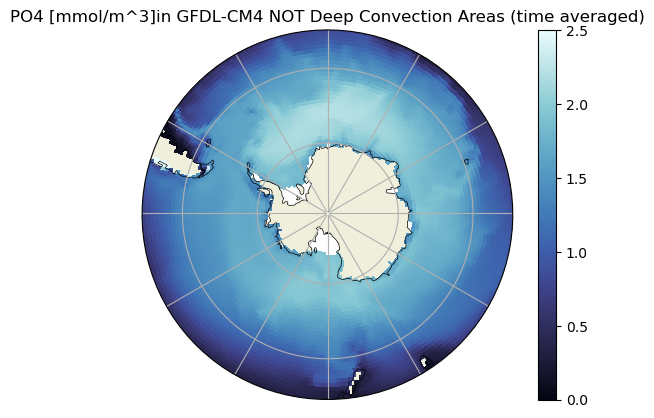

In [68]:
import cartopy.crs as ccrs # for map projections
import cartopy.feature as cfeature # for map features like coastline, etc.
from cartopy.util import add_cyclic_point # get rid of the white line at 0 degree longitude for some models
import matplotlib.path as mpath
import cmocean # a nice collection of colormap

ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
PO4_NOTdeepconvection_plot_c = PO4_NOTdeepconvection_plot * 10**3 #mol/m^3 to mmol/m3
# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(PO4_NOTdeepconvection_plot.lon, PO4_NOTdeepconvection_plot.lat, PO4_NOTdeepconvection_plot_c, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice, vmin = 0, vmax = 2.5) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('PO4 [mmol/m^3]in GFDL-CM4 NOT Deep Convection Areas (time averaged)') 

## Total Deep Convection Areas 

In [17]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_total_Convection = (convection_total_mask== 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_total_Convection_aligned, VAR_aligned = xr.align(mask_total_Convection, MODEL_VAR_SO_sept_surface)

VAR_total_convection = VAR_aligned.where(mask_total_Convection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
VAR_total_convection

<xarray.Dataset> Size: 540MB
Dimensions:    (time: 500, lat: 50, lon: 360, bnds: 2)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    geolat     (time, lat, lon) float32 36MB dask.array<chunksize=(240, 50, 360), meta=np.ndarray>
    geolon     (time, lat, lon) float32 36MB dask.array<chunksize=(240, 50, 360), meta=np.ndarray>
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(240, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(240, 360, 2, 50), meta=np.ndarray>
    spco2      (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d79706ae-6a8c-4765-ad20-7cb43ec718eb
    variable_id:            spco2
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [18]:
#flatten time dimension (average over time), pull po4 data//
##to make the dataset into a (flat) dataarray that can be mapped 
### renamed "_plot" version to preserve original dataset for future computations" 
VAR_total_convection_plot = VAR_total_convection[variable].mean("time")
#ensure dimensions align with expectations (360 x (longitude), 50 y (latitude) 
VAR_total_convection_plot

<xarray.DataArray 'spco2' (lat: 50, lon: 360)> Size: 72kB
dask.array<mean_agg-aggregate, shape=(50, 360), dtype=float32, chunksize=(50, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

**Create Map of Total Convection Area of Variable**

Text(0.5, 1.0, 'PCO2 (Pa) in GFDL-CM4 Total Deep Convection Areas (time averaged)')

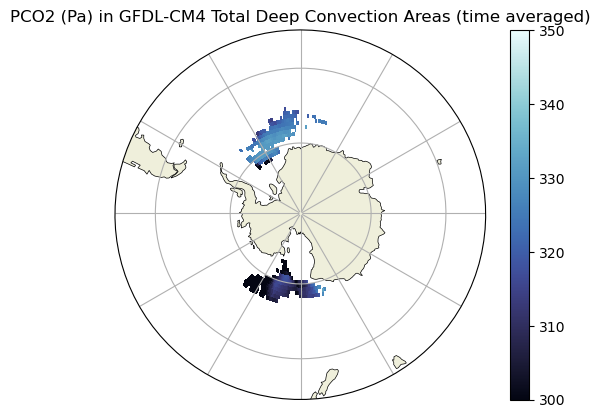

In [19]:
#mapping code 
ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
VAR_total_convection_plot_c = (VAR_total_convection_plot* 1000) / 101.325
# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(VAR_total_convection_plot.lon, VAR_total_convection_plot.lat, VAR_total_convection_plot_c, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice, vmin=300, vmax = 350) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('PCO2 (Pa) in GFDL-CM4 Total Deep Convection Areas (time averaged)') 

**Count Number of Data Points in this Catagory**

In [20]:
n_data_totalconvection = (VAR_total_convection[variable]).count().compute().values
n_data_totalconvection

array(277500)

**Calculate Mean**

In [25]:
VAR_total_convection_MEAN = VAR_total_convection[variable].mean('time').mean('lat').mean('lon').values
VAR_total_convection_MEAN = (VAR_total_convection_MEAN * 1000) / 101.325
VAR_total_convection_MEAN

314.6955639293039

**Timeseries Plot**

Text(0.5, 1.0, 'September PCO2 and MLD in Total Deep Convection Region through Time')

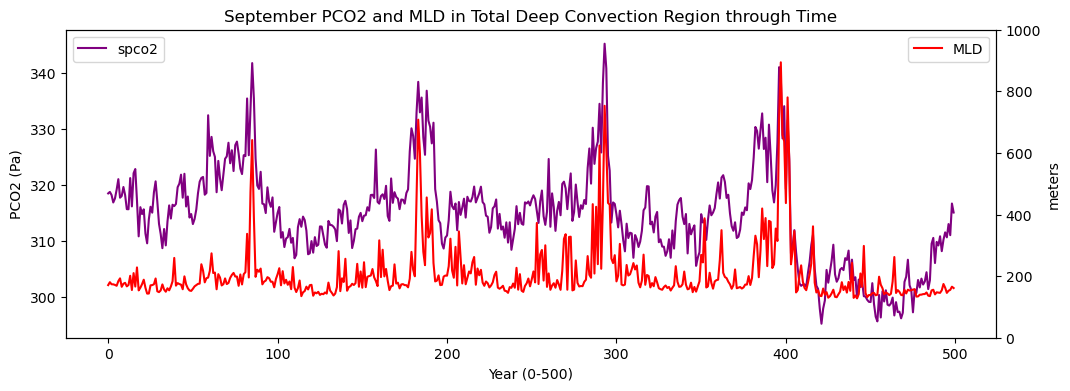

In [27]:
VAR_total_convection_timeseries = VAR_total_convection[variable].mean('lat').mean('lon').values

MLD_total_convection = MODEL_MLD_SO_sept.where(mask_total_Convection['mlotst'])
MLD_total_convection_timeseries = MLD_total_convection['mlotst'].mean('lat').mean('lon').values
years = np.arange(0, 500, 1)


# Create figure
fig, ay1 = plt.subplots(figsize=(12, 4))

# Plot with first x-axis
ay1.plot(years, (VAR_total_convection_timeseries * 1000) / 101.325, color ="purple", label ="spco2")
ay1.set_xlabel("Year (0-500)")
ay1.set_ylabel("PCO2 (Pa)")
ay1.legend(loc="upper left")

# Create second y-axis 
ay2 = ay1.twinx()
ay2.plot(years, MLD_total_convection_timeseries, color ="red", label ="MLD")
ay2.set_ylabel("meters")
ay2.set_ylim(0,1000)
ay2.legend(loc="upper right")
             
plt.title("September PCO2 and MLD in Total Deep Convection Region through Time") 

## Not deep convective in total convective area 

This takes the nutrient that is in the total convective area (feild above) (500 time steps, only data in the total convective areas (nans elsewhere)), and then masks it with the Not deep convection mask (500 yrs, lat below -40, all log), effectively removing all the data points here that are considered deep convection in the convective area 

In [28]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_NOTdeepConvection = (NOTconvection_area_mask == 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#uses the PO4 data, filtered in the total convective area from above
mask_NOTdeepConvection_aligned, VAR_aligned = xr.align(mask_NOTdeepConvection, VAR_total_convection)

VAR_NOTdeepconvection_ConvArea = VAR_aligned.where(mask_NOTdeepConvection_aligned['mlotst'])

# ensure correct variables and dimensions preserved 
VAR_NOTdeepconvection_ConvArea 

<xarray.Dataset> Size: 540MB
Dimensions:    (time: 500, lat: 50, lon: 360, bnds: 2)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
Dimensions without coordinates: bnds
Data variables:
    geolat     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    geolon     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    spco2      (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d79706ae-6a8c-4765-ad20-7cb43ec718eb
    variable_id:            spco2
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [29]:
#flatten time dimension (average over time), pull po4 data//
##to make the dataset into a (flat) dataarray that can be mapped 
### renamed "_plot" version to preserve original dataset for future computations" 
VAR_NOTdeepconvection_ConvArea_plot = VAR_NOTdeepconvection_ConvArea[variable].mean("time")

#ensure dimensions align with expectations (360 x (longitude), 50 y (latitude) 
VAR_NOTdeepconvection_ConvArea_plot

<xarray.DataArray 'spco2' (lat: 50, lon: 360)> Size: 72kB
dask.array<mean_agg-aggregate, shape=(50, 360), dtype=float32, chunksize=(50, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

**Create Map of Convection area, Non- DeepConvection**

Text(0.5, 1.0, 'PCO2 [pa] in GFDL-CM4 Convection Area NOT Deep Convection (time averaged)')

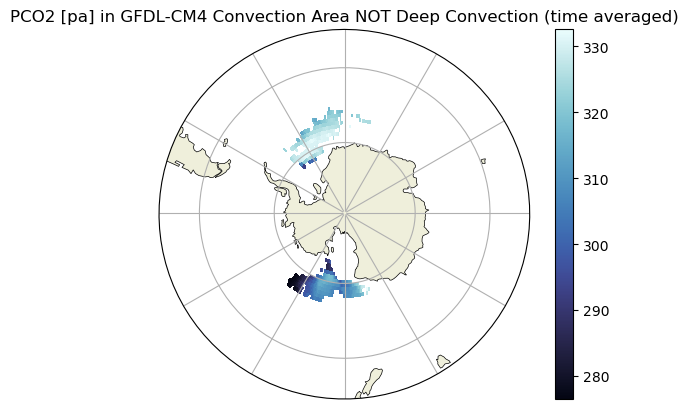

In [30]:
#mapping
ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# add some map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# add gridline
gl = ax.gridlines(
    xlocs = np.arange(-180,180,30),
    ylocs = np.arange(-90,90,20))

## Unit conversion 
VAR_NOTdeepconvection_ConvArea_plot_c = (VAR_NOTdeepconvection_ConvArea_plot* 1000) / 101.325 #mol/m^3 to umol/m3
# use pcolormesh to plot the 2D data array
im = ax.pcolormesh(VAR_NOTdeepconvection_ConvArea_plot.lon, VAR_NOTdeepconvection_ConvArea_plot.lat, VAR_NOTdeepconvection_ConvArea_plot_c, 
                   transform=ccrs.PlateCarree(), # indicate the coordinate system 
                   cmap=cmocean.cm.ice) # use colormap from cmocean

cbar = plt.colorbar(im) # plot colorbar

plt.title('PCO2 [pa] in GFDL-CM4 Convection Area NOT Deep Convection (time averaged)') 

**Count Number of Data Points in this Catagory**

In [31]:
n_data_NotDeep_convectionarea = (VAR_NOTdeepconvection_ConvArea[variable]).count().compute().values
n_data_NotDeep_convectionarea

array(275438)

**Calculate Mean PO4**

In [32]:
VAR_NOTdeepconvection_ConvArea_MEAN = VAR_NOTdeepconvection_ConvArea[variable].mean('time').mean('lat').mean('lon').values
VAR_NOTdeepconvection_ConvArea_MEAN = (VAR_NOTdeepconvection_ConvArea_MEAN * 1000) / 101.325
VAR_NOTdeepconvection_ConvArea_MEAN 

314.27981557594296

## Significance Testing

In [33]:
# Flatten and drop NaNs
deep = VAR_deepconvection[variable].values.flatten()
notdeep = VAR_NOTdeepconvection_ConvArea[variable].values.flatten()

deep = deep[~np.isnan(deep)]
notdeep = notdeep[~np.isnan(notdeep)]

# Welch’s t-test
t_stat, p_val = stats.ttest_ind(deep, notdeep, equal_var=False)
print("Welch’s t-test:", t_stat, p_val)

# Mann–Whitney U
u_stat, p_val = stats.mannwhitneyu(deep, notdeep, alternative="two-sided")
print("Mann–Whitney U:", u_stat, p_val)


Welch’s t-test: 74.90381478698332 0.0
Mann–Whitney U: 543026512.0 0.0


**Effect size (Cohen’s d or median difference)**

In [34]:
mean_deep = np.nanmean(deep)
mean_notdeep = np.nanmean(notdeep)
std_pooled = np.sqrt(((np.nanstd(deep, ddof=1) ** 2) + (np.nanstd(notdeep, ddof=1) ** 2)) / 2)

cohens_d = (mean_deep - mean_notdeep) / std_pooled
print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 2.088


In [35]:
u_stat, p_val = stats.mannwhitneyu(deep, notdeep, alternative='two-sided')
n1, n2 = len(deep), len(notdeep)

rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Rank-biserial correlation: -0.912


In [36]:
median_diff = np.nanmedian(deep) - np.nanmedian(notdeep)
print(f"Median difference: {median_diff:.3f}")

Median difference: 5.186


In [37]:
##calculated mld output

## u/home/rwang/output_files/GFDL-CM4/GFDL-CM4_cal_mld_gn_SO_sep_mld.nc

## Bootstrapping stats 

Welch’s t-test:
  Mean t = 67.063, Mean p = 0.000000e+00
  Cohen’s d = 2.089 (std 0.016)

Mann–Whitney U test:
  Mean U = 186647.441, Mean p = 0.000000e+00
  Rank-biserial corr = 0.999 (std 0.000)


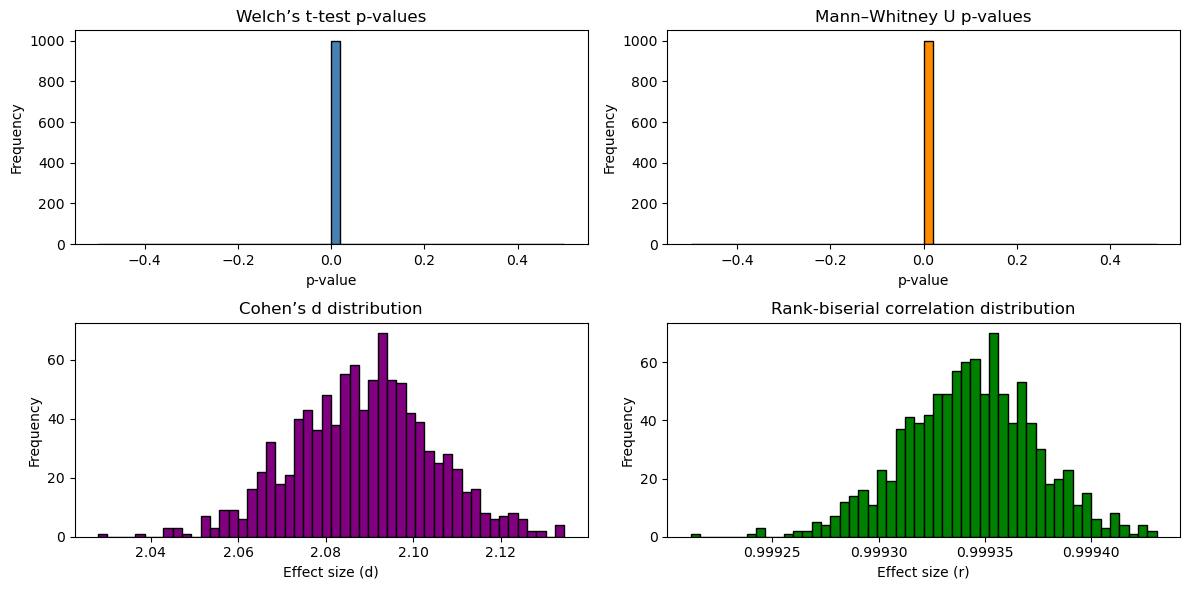

In [38]:
deep = VAR_deepconvection[variable].values.flatten()
notdeep = VAR_NOTdeepconvection_ConvArea[variable].values.flatten()

# drop NaNs
deep = deep[~np.isnan(deep)]
notdeep = notdeep[~np.isnan(notdeep)]

n_deep = len(deep)
n_boot = 1000  # number of bootstrap iterations

t_stats, p_vals_t, cohens_d = [], [], []
u_stats, p_vals_u, rbc = [], [], []

rng = np.random.default_rng(42)  # reproducible

for i in range(n_boot):
    # subsample notdeep to match deep
    notdeep_sub = rng.choice(notdeep, size=n_deep, replace=False)

    # Welch’s t-test
    t_stat, p_val = stats.ttest_ind(deep, notdeep_sub, equal_var=False)
    t_stats.append(t_stat)
    p_vals_t.append(p_val)

    # Cohen’s d (effect size for means)
    mean_diff = np.mean(deep) - np.mean(notdeep_sub)
    pooled_std = np.sqrt(((np.std(deep, ddof=1) ** 2) + (np.std(notdeep_sub, ddof=1) ** 2)) / 2)
    cohens_d.append(mean_diff / pooled_std)

    # Mann–Whitney U test
    u_stat, p_val_u = stats.mannwhitneyu(notdeep_sub,deep, alternative='two-sided')
    u_stats.append(u_stat)
    p_vals_u.append(p_val_u)

    # Rank-biserial correlation (effect size for Mann–Whitney)
    n1, n2 = len(notdeep), len(deep)
    r = 1 - (2 * u_stat) / (n1 * n2)
    rbc.append(r)

# ---- Summary ----
print("Welch’s t-test:")
print(f"  Mean t = {np.mean(t_stats):.3f}, Mean p = {np.mean(p_vals_t):.6e}")
print(f"  Cohen’s d = {np.mean(cohens_d):.3f} (std {np.std(cohens_d):.3f})")

print("\nMann–Whitney U test:")
print(f"  Mean U = {np.mean(u_stats):.3f}, Mean p = {np.mean(p_vals_u):.6e}")
print(f"  Rank-biserial corr = {np.mean(rbc):.3f} (std {np.std(rbc):.3f})")

# ---- Plots ----
plt.figure(figsize=(12,6))

# p-values
plt.subplot(2,2,1)
plt.hist(p_vals_t, bins=50, color='steelblue', edgecolor='black')
plt.title("Welch’s t-test p-values")
plt.xlabel("p-value"); plt.ylabel("Frequency")

plt.subplot(2,2,2)
plt.hist(p_vals_u, bins=50, color='darkorange', edgecolor='black')
plt.title("Mann–Whitney U p-values")
plt.xlabel("p-value"); plt.ylabel("Frequency")

# effect sizes
plt.subplot(2,2,3)
plt.hist(cohens_d, bins=50, color='purple', edgecolor='black')
plt.title("Cohen’s d distribution")
plt.xlabel("Effect size (d)"); plt.ylabel("Frequency")

plt.subplot(2,2,4)
plt.hist(rbc, bins=50, color='green', edgecolor='black')
plt.title("Rank-biserial correlation distribution")
plt.xlabel("Effect size (r)"); plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
